# 04 - Statistical Analysis


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/cleaned_data.csv')

Matplotlib is building the font cache; this may take a moment.


<class 'pandas.DataFrame'>
RangeIndex: 30926 entries, 0 to 30925
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 30926 non-null  str    
 1   rating                30926 non-null  float64
 2   number_of_reviews     30926 non-null  int64  
 3   bought_in_last_month  30926 non-null  int64  
 4   listed_price          30926 non-null  float64
 5   is_best_seller        30926 non-null  int64  
 6   is_sponsored          30926 non-null  int64  
 7   buy_box_availability  27880 non-null  str    
 8   delivery_details      30813 non-null  str    
 9   image_url             30926 non-null  str    
 10  product_url           29137 non-null  str    
 11  collected_at          30926 non-null  str    
 12  current_price         30926 non-null  float64
 13  has_coupon            30926 non-null  int64  
 14  is_sustainable        30926 non-null  int64  
dtypes: float64(3), int64(6), str(6

In [5]:
%pip install seaborn scipy scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Correlation Analysis

#### Usecase

Quality Indicators - If number_of_reviews is highly correlated with rating, it means popular products maintain quality

Price Strategy - If current_price is negatively correlated with rating, expensive products get lower ratings → consider price adjustments

Marketing ROI - If is_sponsored correlates with high ratings, sponsorships improve perception

Feature Importance - "What actually drives ratings? Is it reviews, price, best-seller status, or coupons?"

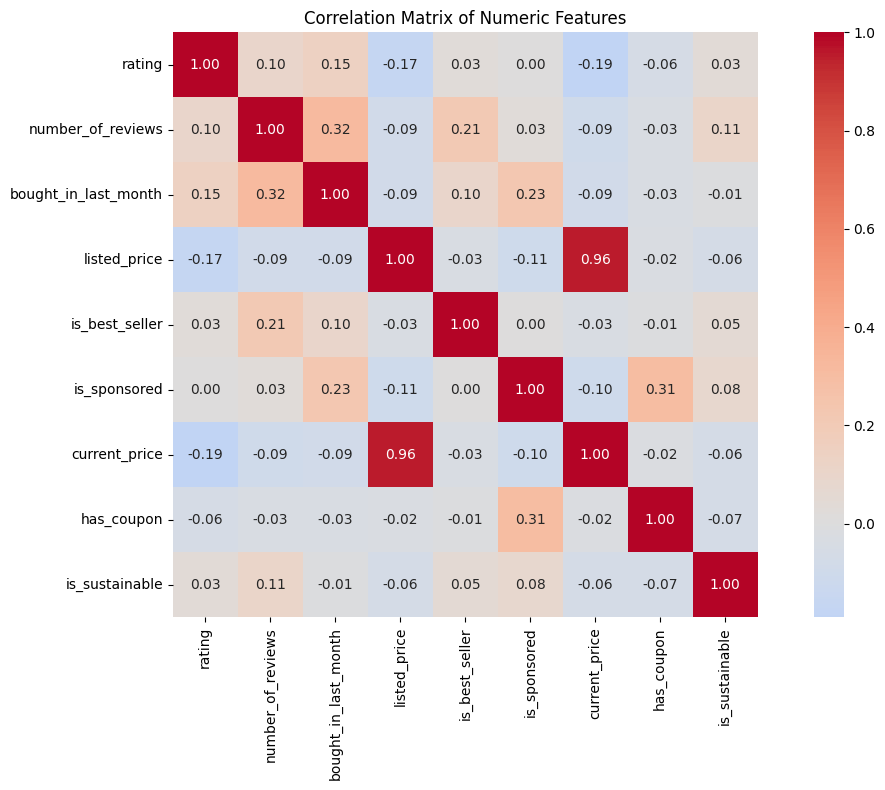


Correlation with Rating:
rating                  1.000000
bought_in_last_month    0.146268
number_of_reviews       0.095095
is_sustainable          0.033757
is_best_seller          0.025933
is_sponsored            0.000731
has_coupon             -0.059141
listed_price           -0.165568
current_price          -0.190334
Name: rating, dtype: float64


In [6]:
# 1. CORRELATION ANALYSIS

import numpy as np
import seaborn as sns
from scipy import stats

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# Print correlation with rating
print("\nCorrelation with Rating:")
print(correlation_matrix['rating'].sort_values(ascending=False))

## 2. Hypothesis Testing


#### Usecase
Test 1:

Pricing Confidence - If p-value < 0.05, price truly affects rating (not random)

Discount Strategy - If high-price products are rated lower → run promotional pricing test

Test 2:

Algorithm Validation - Does Amazon's "Best Seller" badge correlate with actual quality?

Competitive Strategy - Aim products toward best-seller status if it truly means quality

Test 3:

Marketing ROI - If coupons significantly boost purchases → budget for coupon campaigns

Discount Strategy - "Should we use coupons or just lower base price?"

In [ ]:
# Test 1: Does price affect rating? (T-test: high price vs low price)
median_price = df['current_price'].median()
high_price = df[df['current_price'] >= median_price]['rating']
low_price = df[df['current_price'] < median_price]['rating']

t_stat, p_value = stats.ttest_ind(high_price, low_price)
print("T-Test: High Price vs Low Price Rating:")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.6f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")

# Test 2: Best sellers have higher ratings? 
best_sellers = df[df['is_best_seller'] == 1]['rating']
non_best_sellers = df[df['is_best_seller'] == 0]['rating']

t_stat2, p_value2 = stats.ttest_ind(best_sellers, non_best_sellers)
print("\nT-Test: Best Sellers vs Non-Best Sellers:")
print(f"Best sellers avg rating: {best_sellers.mean():.2f}")
print(f"Non-best sellers avg rating: {non_best_sellers.mean():.2f}")
print(f"T-statistic: {t_stat2:.4f}, P-value: {p_value2:.6f}")
print(f"Significant: {'Yes' if p_value2 < 0.05 else 'No'}")

# Test 3: Does coupon availability affect purchases?
with_coupon = df[df['has_coupon'] == 1]['bought_in_last_month']
without_coupon = df[df['has_coupon'] == 0]['bought_in_last_month']

t_stat3, p_value3 = stats.ttest_ind(with_coupon, without_coupon)
print("\nT-Test: Coupon Impact on Purchases:")
print(f"With coupon avg purchases: {with_coupon.mean():.2f}")
print(f"Without coupon avg purchases: {without_coupon.mean():.2f}")
print(f"T-statistic: {t_stat3:.4f}, P-value: {p_value3:.6f}")
print(f"Significant: {'Yes' if p_value3 < 0.05 else 'No'}")

T-Test: High Price vs Low Price Rating:
T-statistic: -41.1644, P-value: 0.000000
Significant: Yes

T-Test: Best Sellers vs Non-Best Sellers:
Best sellers avg rating: 4.54
Non-best sellers avg rating: 4.42
T-statistic: 4.5620, P-value: 0.000005
Significant: Yes

T-Test: Coupon Impact on Purchases:
With coupon avg purchases: 435.42
Without coupon avg purchases: 1288.47
T-statistic: -5.7724, P-value: 0.000000
Significant: Yes


## 3. Linear Regression

Predicts product rating based on 8 features. Shows which factors matter most

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Prepare features for regression (predicting rating)
features = ['number_of_reviews', 'bought_in_last_month', 'listed_price', 
            'current_price', 'is_best_seller', 'is_sponsored', 'has_coupon', 'is_sustainable']
X = df[features].fillna(df[features].mean())
y = df['rating']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit linear regression
model = LinearRegression()
model.fit(X_scaled, y)

# Calculate metrics
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Linear Regression: Predicting Rating")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print("\nFeature Importance (Coefficients):")
for feature, coef in sorted(zip(features, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feature}: {coef:.4f}")

# Price sensitivity regression
print("\nPrice Sensitivity Analysis:")
X_price = df[['current_price']].fillna(df['current_price'].mean())
price_model = LinearRegression()
price_model.fit(X_price, y)
print(f"Price coefficient: {price_model.coef_[0]:.6f} (rating change per $1)")

Linear Regression: Predicting Rating
R² Score: 0.0620
RMSE: 0.3683

Feature Importance (Coefficients):
  current_price: -0.1347
  listed_price: 0.0699
  bought_in_last_month: 0.0479
  has_coupon: -0.0165
  number_of_reviews: 0.0139
  is_sponsored: -0.0128
  is_sustainable: 0.0078
  is_best_seller: -0.0006

Price Sensitivity Analysis:
Price coefficient: -0.000186 (rating change per $1)


## 4. Percentile Analysis

Identify performance benchmarks and segment products by quality/sales tiers

In [20]:
# Calculate percentiles
print("Percentile Analysis \n")

# Rating percentiles
print("RATING PERCENTILES:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = df['rating'].quantile(p/100)
    print(f"  {p}th percentile: {val:.2f}")

# Top 10% products by rating
top_10_rating = df['rating'].quantile(0.90)
top_10_products = df[df['rating'] >= top_10_rating]
print(f"\nTop 10% Products by Rating (rating >= {top_10_rating:.2f}):")
print(f"  Count: {len(top_10_products)}")
print(f"  Avg Reviews: {top_10_products['number_of_reviews'].mean():.0f}")
print(f"  Avg Price: ${top_10_products['current_price'].mean():.2f}")
print(f"  Best Seller %: {top_10_products['is_best_seller'].mean()*100:.1f}%")

# Top 10% products by reviews
top_10_reviews = df['number_of_reviews'].quantile(0.90)
top_10_reviewed = df[df['number_of_reviews'] >= top_10_reviews]
print(f"\nTop 10% Products by Reviews (reviews >= {top_10_reviews:.0f}):")
print(f"  Count: {len(top_10_reviewed)}")
print(f"  Avg Rating: {top_10_reviewed['rating'].mean():.2f}")
print(f"  Avg Price: ${top_10_reviewed['current_price'].mean():.2f}")
print(f"  Best Seller %: {top_10_reviewed['is_best_seller'].mean()*100:.1f}%")

# Top 10% products by purchases
top_10_purchases = df['bought_in_last_month'].quantile(0.90)
top_10_purchased = df[df['bought_in_last_month'] >= top_10_purchases]
print(f"\nTop 10% Products by Purchases (purchases >= {top_10_purchases:.0f}):")
print(f"  Count: {len(top_10_purchased)}")
print(f"  Avg Rating: {top_10_purchased['rating'].mean():.2f}")
print(f"  Avg Price: ${top_10_purchased['current_price'].mean():.2f}")
print(f"  Best Seller %: {top_10_purchased['is_best_seller'].mean()*100:.1f}%")

Percentile Analysis 

RATING PERCENTILES:
  10th percentile: 4.00
  25th percentile: 4.30
  50th percentile: 4.50
  75th percentile: 4.70
  90th percentile: 4.80
  95th percentile: 4.80
  99th percentile: 5.00

Top 10% Products by Rating (rating >= 4.80):
  Count: 5046
  Avg Reviews: 5595
  Avg Price: $169.14
  Best Seller %: 0.5%

Top 10% Products by Reviews (reviews >= 5591):
  Count: 3124
  Avg Rating: 4.60
  Avg Price: $52.34
  Best Seller %: 3.9%

Top 10% Products by Purchases (purchases >= 1000):
  Count: 3941
  Avg Rating: 4.61
  Avg Price: $52.37
  Best Seller %: 4.4%


## 5. Categorical Relationship Tests

Test if two marketing tactics are statistically related (not just coincidence)

Chi-Square Tests for Categorical Relationships

1. Best Seller vs Has Coupon:
has_coupon          0     1
is_best_seller             
0               28760  1941
1                 218     7
   Chi-square = 3.3772, p-value = 0.066103
   Significant: No

2. Best Seller vs Is Sponsored:
is_sponsored        0     1
is_best_seller             
0               23758  6943
1                 170    55
   Chi-square = 0.3289, p-value = 0.566289
   Significant: No

3. Best Seller vs Is Sustainable:
is_sustainable      0     1
is_best_seller             
0               28443  2258
1                 174    51
   Chi-square = 73.5994, p-value = 0.000000
   Significant: Yes

4. Has Coupon vs Is Sponsored:
is_sponsored      0     1
has_coupon               
0             23385  5593
1               543  1405
   Chi-square = 2906.1599, p-value = 0.000000
   Significant: Yes



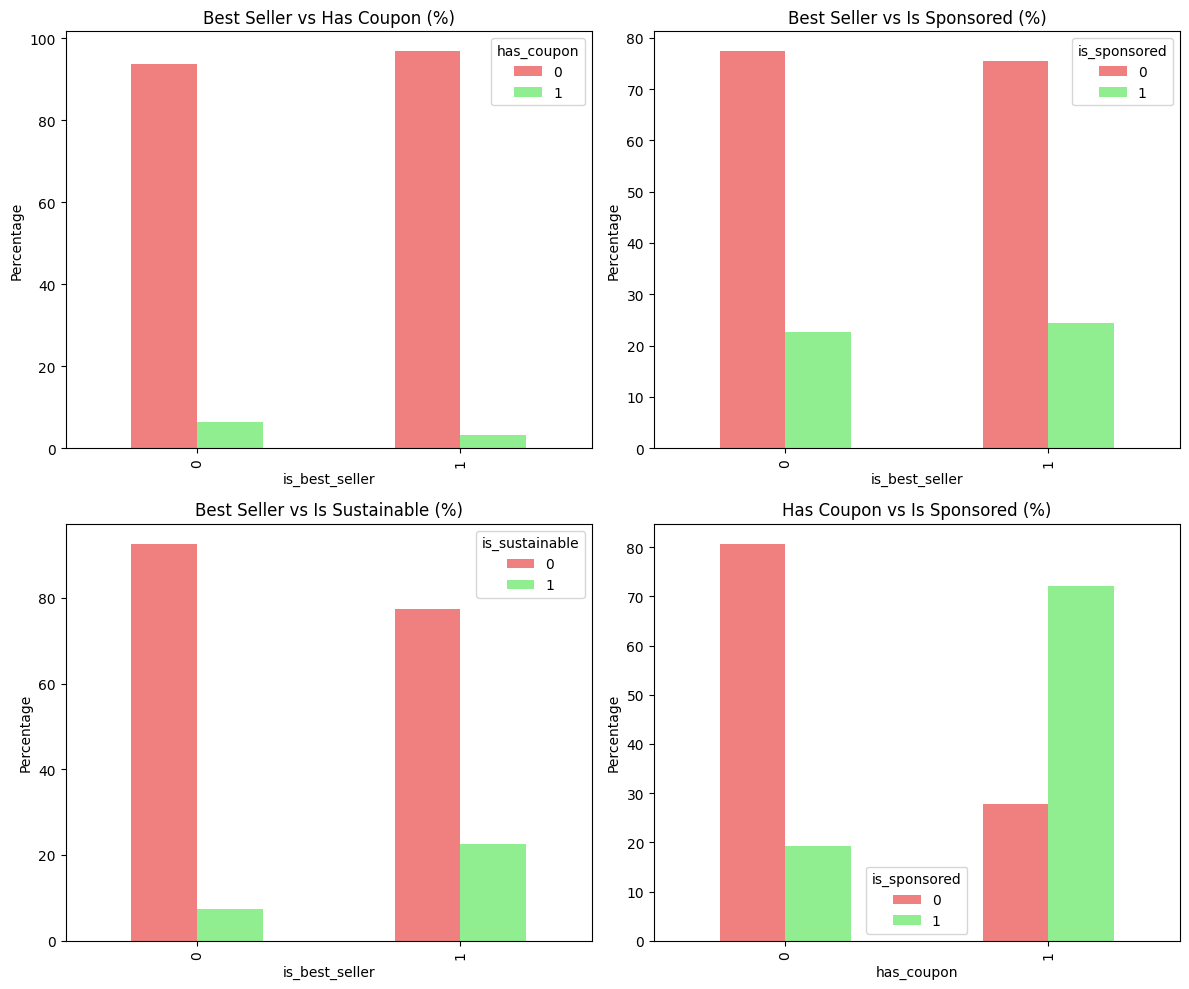

In [22]:
from scipy.stats import chi2_contingency

print("Chi-Square Tests for Categorical Relationships\n")

# Test 1: Best Seller vs Has Coupon
contingency_table1 = pd.crosstab(df['is_best_seller'], df['has_coupon'])
chi2_1, p_val_1, dof_1, expected_1 = chi2_contingency(contingency_table1)
print("1. Best Seller vs Has Coupon:")
print(contingency_table1)
print(f"   Chi-square = {chi2_1:.4f}, p-value = {p_val_1:.6f}")
print(f"   Significant: {'Yes' if p_val_1 < 0.05 else 'No'}\n")

# Test 2: Best Seller vs Is Sponsored
contingency_table2 = pd.crosstab(df['is_best_seller'], df['is_sponsored'])
chi2_2, p_val_2, dof_2, expected_2 = chi2_contingency(contingency_table2)
print("2. Best Seller vs Is Sponsored:")
print(contingency_table2)
print(f"   Chi-square = {chi2_2:.4f}, p-value = {p_val_2:.6f}")
print(f"   Significant: {'Yes' if p_val_2 < 0.05 else 'No'}\n")

# Test 3: Best Seller vs Is Sustainable
contingency_table3 = pd.crosstab(df['is_best_seller'], df['is_sustainable'])
chi2_3, p_val_3, dof_3, expected_3 = chi2_contingency(contingency_table3)
print("3. Best Seller vs Is Sustainable:")
print(contingency_table3)
print(f"   Chi-square = {chi2_3:.4f}, p-value = {p_val_3:.6f}")
print(f"   Significant: {'Yes' if p_val_3 < 0.05 else 'No'}\n")

# Test 4: Has Coupon vs Is Sponsored
contingency_table4 = pd.crosstab(df['has_coupon'], df['is_sponsored'])
chi2_4, p_val_4, dof_4, expected_4 = chi2_contingency(contingency_table4)
print("4. Has Coupon vs Is Sponsored:")
print(contingency_table4)
print(f"   Chi-square = {chi2_4:.4f}, p-value = {p_val_4:.6f}")
print(f"   Significant: {'Yes' if p_val_4 < 0.05 else 'No'}\n")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Convert to percentages for better visualization
contingency1_pct = contingency_table1.div(contingency_table1.sum(axis=1), axis=0) * 100
contingency1_pct.plot(kind='bar', ax=axes[0, 0], color=['lightcoral', 'lightgreen'])
axes[0, 0].set_title('Best Seller vs Has Coupon (%)')
axes[0, 0].set_ylabel('Percentage')

contingency2_pct = contingency_table2.div(contingency_table2.sum(axis=1), axis=0) * 100
contingency2_pct.plot(kind='bar', ax=axes[0, 1], color=['lightcoral', 'lightgreen'])
axes[0, 1].set_title('Best Seller vs Is Sponsored (%)')
axes[0, 1].set_ylabel('Percentage')

contingency3_pct = contingency_table3.div(contingency_table3.sum(axis=1), axis=0) * 100
contingency3_pct.plot(kind='bar', ax=axes[1, 0], color=['lightcoral', 'lightgreen'])
axes[1, 0].set_title('Best Seller vs Is Sustainable (%)')
axes[1, 0].set_ylabel('Percentage')

contingency4_pct = contingency_table4.div(contingency_table4.sum(axis=1), axis=0) * 100
contingency4_pct.plot(kind='bar', ax=axes[1, 1], color=['lightcoral', 'lightgreen'])
axes[1, 1].set_title('Has Coupon vs Is Sponsored (%)')
axes[1, 1].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

## 6. Sales Forcasting 

#### Usecase
Say you have a product with 800 reviews generating 300 purchases/month, but the model predicts 450. This 150-unit gap suggests:

-Pricing might be too high 

-Marketing/visibility issue

-Quality concerns despite positive reviews


Estimated Monthly Purchases based on Review Count:

100 reviews → approx. 774 purchases/month
500 reviews → approx. 835 purchases/month
1000 reviews → approx. 910 purchases/month
2000 reviews → approx. 1061 purchases/month
5000 reviews → approx. 1515 purchases/month


/Users/moulisrivastava/Desktop/E_G1_DVACapstone2/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


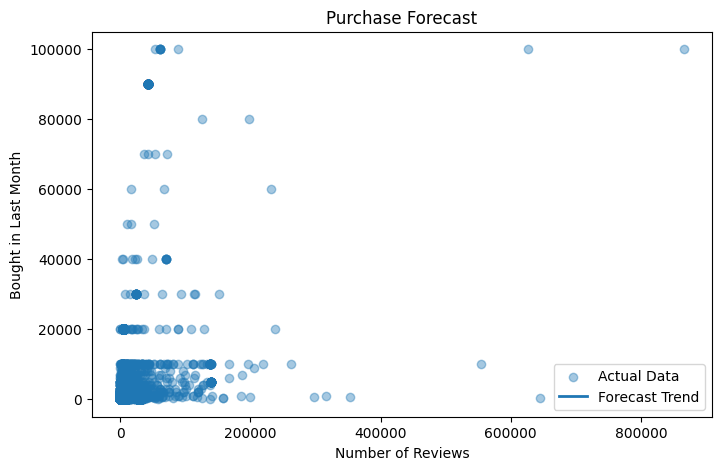

In [27]:
# Function for smoother and easier purchase forecasting
def purchase_forecast(df):

    # Use only clean numeric values
    df_model = df[['number_of_reviews', 'bought_in_last_month']].copy()
    df_model = df_model.dropna()

    # Features and target
    X = df_model[['number_of_reviews']]
    y = df_model['bought_in_last_month']

    # Simple Linear Regression (easier to explain than polynomial)
    model = LinearRegression()
    model.fit(X, y)

    # Predict for common review milestones
    forecast_reviews = np.array([[100], [500], [1000], [2000], [5000]])

    forecast_purchases = model.predict(forecast_reviews)

    print("Estimated Monthly Purchases based on Review Count:\n")
    for reviews, purchases in zip(forecast_reviews.flatten(), forecast_purchases):
        print(f"{reviews} reviews → approx. {max(0, purchases):.0f} purchases/month")

    # Plot for better understanding
    plt.figure(figsize=(8,5))
    plt.scatter(X, y, alpha=0.4, label="Actual Data")
    plt.plot(
        forecast_reviews,
        forecast_purchases,
        linewidth=2,
        label="Forecast Trend"
    )

    plt.xlabel("Number of Reviews")
    plt.ylabel("Bought in Last Month")
    plt.title("Purchase Forecast")
    plt.legend()
    plt.show()


# Run the function
purchase_forecast(df)